# This ist ein attempt at trying to kombinée les token data und dataframe from ein model in pytorchencoder.

# Use this to make dimensionality reduction via UMAP such that it may be used for clustering.



# WHen this ist vertig, import the optimised modellen von dem richtiges bild und use that with this method to make le best possible clustering, ja?

In [1]:
import umap.umap_ as umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler

In [2]:
# Load encoded image features
df_img = pd.read_csv("encoded_unique.csv")

print(df_img.shape)  # (N, 91) Yes yes yes

(3193, 91)


In [3]:
def data_processor(path):
    text_list = []
    data = pd.read_csv(path).fillna("")
    
    for _, row in data.iterrows():
        text_list.append(
            f"{row['title']} {row['subtitle']} {row['country']} {row['club']}"
        )
        
    return data, text_list

# Load same dataset (IMPORTANT: same ordering as encoder!)
path = r"..\..\data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv"
df_text, text_list = data_processor(path)

# Vectorize
vectorizer = CountVectorizer(max_features=5000)  # limit size (important!)
X_text = vectorizer.fit_transform(text_list)

print(X_text.shape)


(3193, 3648)


In [4]:
X_text_dense = X_text.toarray()  # convert sparse → dense
X_img = df_img.values           # numpy array

print(X_img.shape)
print(X_text_dense.shape)

(3193, 91)
(3193, 3648)


In [5]:
# Normalise both separately
scaler_img = StandardScaler() 
scaler_text = StandardScaler()

X_img_scaled = scaler_img.fit_transform(X_img)
X_text_scaled = scaler_text.fit_transform(X_text_dense)

In [6]:
# Weighting (IMPORTANT tuning knob)
alpha = 1.0   # image importance
beta  = 0.3   # text importance 

X_combined = np.hstack([
    alpha * X_img_scaled,
    beta  * X_text_scaled
]) #This is how we weight the datasets importance with respect to each other.

print(X_combined.shape)

(3193, 3739)


In [9]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,  # 2D visualization
    random_state=42
)

X_umap = reducer.fit_transform(X_combined)
print(X_umap.shape)  # (N, 2)

c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(3193, 2)


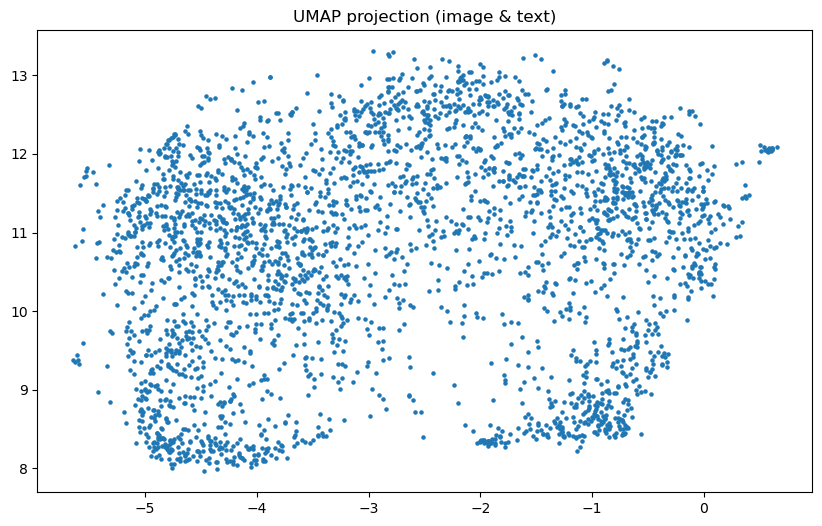

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP projection (image & text)")
plt.show()


In [ ]:
# Now ispection of UMAP PRojection

c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: Us

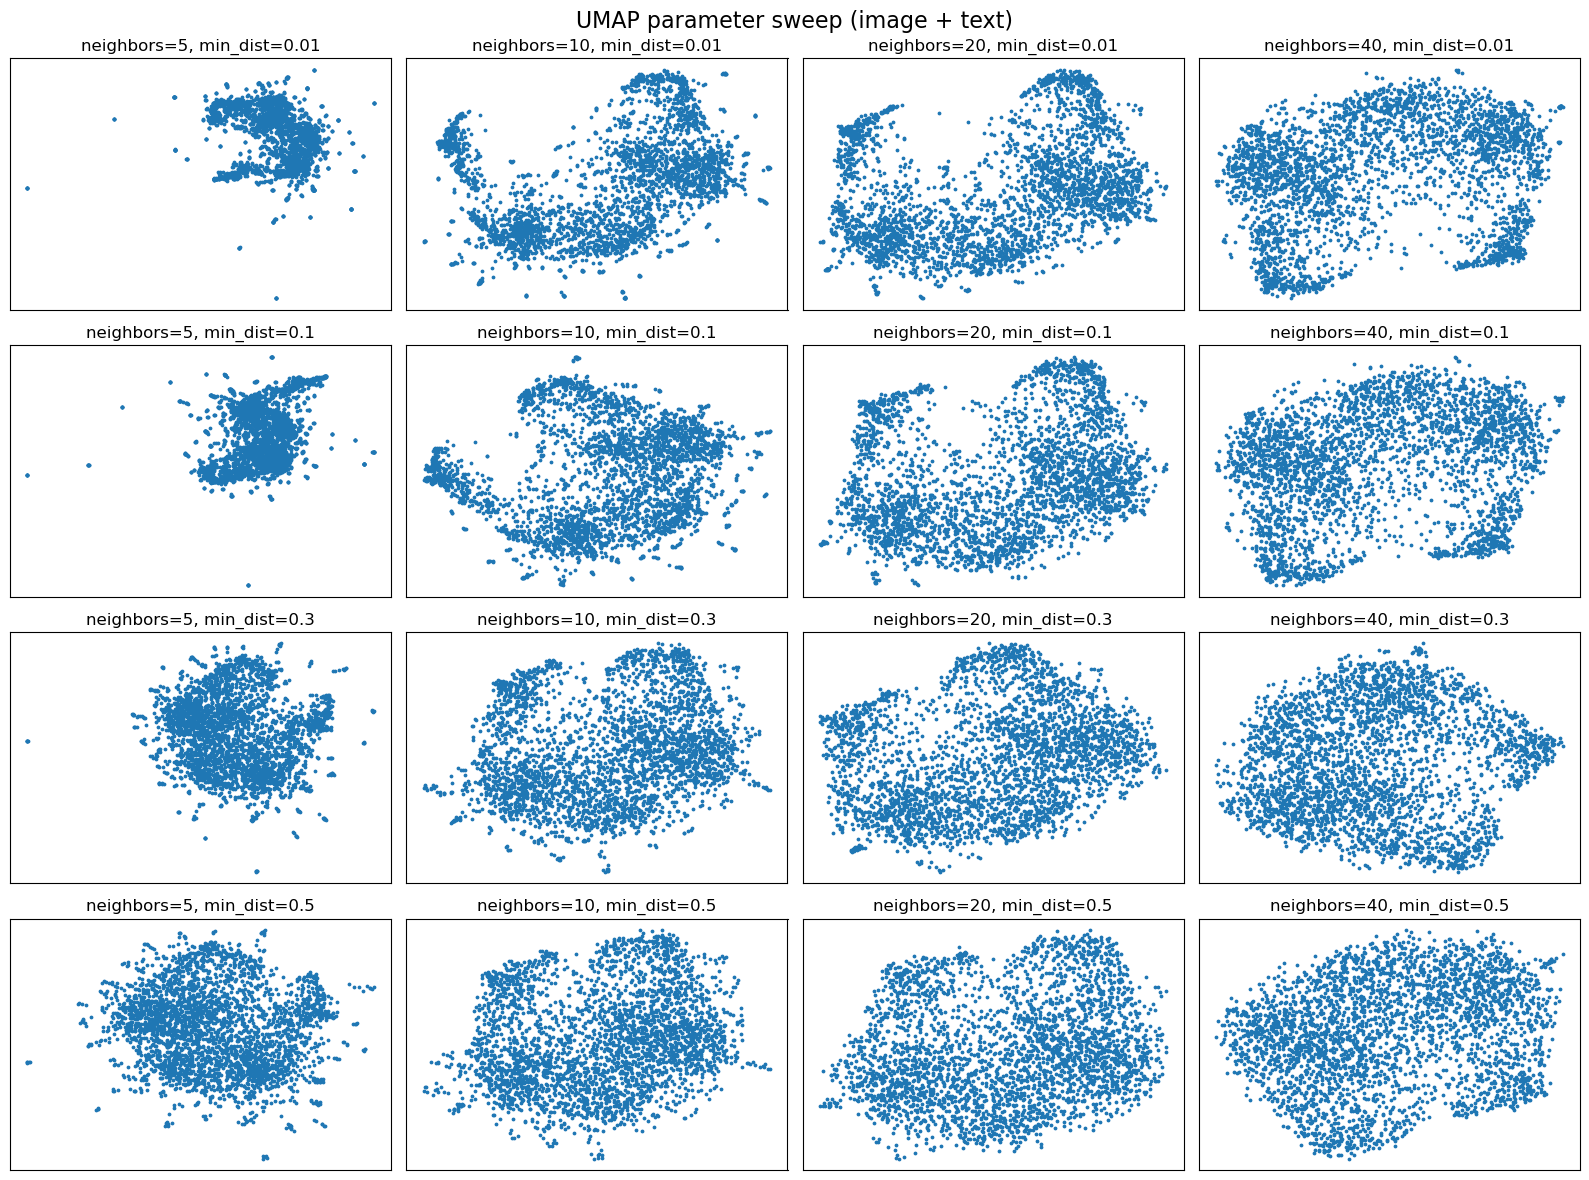

In [11]:
# Parameter ranges
min_dist_list = [0.01, 0.1, 0.3, 0.5]
n_neighbors_list = [5, 10, 20, 40]

# Create subplot grid
fig, axes = plt.subplots(len(min_dist_list), len(n_neighbors_list), figsize=(16, 12))

# Loop over all combinations
for i, min_dist in enumerate(min_dist_list):
    for j, n_neighbors in enumerate(n_neighbors_list):
        
        # Create UMAP reducer with current parameters
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            random_state=42
        )
        
        # Fit and transform
        X_umap = reducer.fit_transform(X_combined)
        
        # Plot in the correct subplot
        ax = axes[i, j]
        ax.scatter(X_umap[:, 0], X_umap[:, 1], s=3)
        
        # Title for each subplot
        ax.set_title(f"neighbors={n_neighbors}, min_dist={min_dist}")
        
        # Remove axis ticks for clarity
        ax.set_xticks([])
        ax.set_yticks([])

# Global title
plt.suptitle("UMAP parameter sweep (image + text)", fontsize=16)

plt.tight_layout()
plt.show()